<a href="https://colab.research.google.com/github/manishcodespace/deeplearn-project/blob/maihttps/BasicNNModel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [41]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [42]:
# create a model class that inherit nn module
# input layer (4 features of the flower) ---> Hidder layer1(Number of neuron) ----> Hidder layer2(Number of neuron) ---->
# Hidden Layer3(Number of neuron)----> output layer
class Model(nn.Module):
  def __init__(self, input_features = 4, h1=8, h2=9, output_features=3):
    super().__init__()
    # Input layer
    self.fc1 = nn.Linear(input_features, h1)
    self.fc2 = nn.Linear(h1, h2)
    self.out = nn.Linear(h2, output_features)

  def forward(self, x):
    x = F.relu(self.fc1(x))
    x = F.relu(self.fc2(x))
    x = self.out(x)

    return x

In [43]:
# pick a manual see of randomization
torch.manual_seed(32)

# create an instance of model
mymodel = Model()

In [44]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [45]:
url = 'https://gist.githubusercontent.com/netj/8836201/raw/6f9306ad21398ea43cba4f7d537619d0e07d5ae3/iris.csv'
my_df = pd.read_csv(url)

In [46]:
my_df.head()

,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa


In [47]:
# change last col to interger
my_df['variety'] = my_df['variety'].replace('Setosa', 0.0)
my_df['variety'] = my_df['variety'].replace('Versicolor', 1.0)
my_df['variety'] = my_df['variety'].replace('Virginica', 2.0)

my_df

/tmp/ipykernel_708/3462210957.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  my_df['variety'] = my_df['variety'].replace('Virginica', 2.0)


,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,0.0
1,4.9,3.0,1.4,0.2,0.0
2,4.7,3.2,1.3,0.2,0.0
3,4.6,3.1,1.5,0.2,0.0
4,5.0,3.6,1.4,0.2,0.0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2.0
146,6.3,2.5,5.0,1.9,2.0
147,6.5,3.0,5.2,2.0,2.0
148,6.2,3.4,5.4,2.3,2.0


In [48]:
# Train test split! set(x, y)

x=my_df.drop('variety', axis=1)
y=my_df['variety']

In [49]:
# convert these two a numpy array
x=x.values
y=y.values

In [50]:
from sklearn.model_selection import train_test_split

# Train test split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=41)

In [51]:
# convert x features into float tensor
X_train = torch.FloatTensor(x_train)
X_test = torch.FloatTensor(x_test)

In [52]:
# convert y features into tensor long
Y_train = torch.LongTensor(y_train)
Y_test = torch.LongTensor(y_test)

In [53]:
import torch.nn as nn

# set criteria of model to measure the error, how far off the prediction are from

criterion = nn.CrossEntropyLoss()

# choose Adam optimizer , lr = learning rate
optimizer = torch.optim.Adam(mymodel.parameters(), lr=0.01)


In [56]:
# Train our model
# Epochs (one run through all the training data in our network)
epochs = 100
losses = []

for i in range(epochs):
  # go forward and get a prediction
  y_pred = mymodel.forward(X_train) # get predicted result

  # Measure the loss/error, gonna be high at first
  loss = criterion(y_pred, Y_train) # pridicted value vs Y_train value

  # keep track of our losses
  losses.append(loss.detach().numpy())

  # print every 10 epoch
  if i % 10 == 0:
    print(f'Epoch: {i} to  loss :{loss}')

  # Do some back propagation: take the error rate of forward propagation and feed it backbard
  # thru network to fine tune weight
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()


Epoch: 0 to  loss :0.01484293770045042
Epoch: 10 to  loss :0.014352998696267605
Epoch: 20 to  loss :0.013885261490941048
Epoch: 30 to  loss :0.013437007553875446
Epoch: 40 to  loss :0.013006106950342655
Epoch: 50 to  loss :0.012591348960995674
Epoch: 60 to  loss :0.012196360155940056
Epoch: 70 to  loss :0.012673535384237766
Epoch: 80 to  loss :0.011457049287855625
Epoch: 90 to  loss :0.011239414103329182


Text(0.5, 0, 'Epoch')

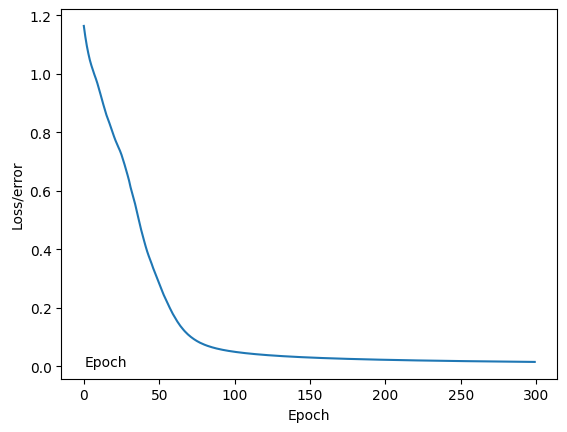

In [55]:
# Graph it out
plt.plot(range(epochs), losses)
plt.ylabel('Loss/error')
plt.xlabel('Epoch')

plt.text(0.5, 0, 'Epoch')
